<div align="center">
    <img src="images/TBM3D/tbm1.png" width="1300">
</div>

3D TBM is used for 3D image analysis and consists of 4 parts: 

Step 1: Pre-processing & preparation for TBM

Step 2: Computing the transport embedding 

Step 3: Statistical analysis

step 4: Visualization

<font size="5">Step 1: Pre-processing & preparation for TBM</font>

Before running the TBM codes, you should prepare your data(i.e. registratoin, segmentation, centralization...).
After preprocessing, all the training and testing images should be numpy files (endwith .npy) with same shape ([h,w,d])

All the training and testing data should be organized in a csv file separately(one file for training, one file for testing), the structure of this file should be like:

    image_path      | label | other variable...
    ./data/0.npy    |   1   | ...
    ./data/1.npy    |   0   | ...
    ...

where the 'image_path' can be read directly, 'label' is the corresponding label. You can organize other variables related to the data into this file, but we don’t need them here.

In this demo program, we have already preprocessed all the data. You can download it using the following link and then extract it to the current directory:

https://drive.google.com/file/d/14K-Q5PzkiFzEUMxDb0984QWIB2VkWpda/view?usp=drive_link

And then, download this file and put it into the 'IXI_data' folder:

https://drive.google.com/file/d/1XhEmU-hvo3oSHO1Ff9foPRnFpOymZ0fw/view?usp=drive_link

<font size="5">Step 2: Computing the transport embedding </font>

After preparing the data, you only need to set the corresponding file path and then you can start running our program. If you can provide the reference, please set the path of reference, the reference should have same shape as images; otherwise, we will use the average of all training images as the reference. And if you already did normalization, set 'normalized = True', otherwise, we will do normalization when loading data.

\* Usually, the normalization[1] is 
<math xmlns="http://www.w3.org/1998/Math/MathML" display="block" id="m1" overflow="scroll" alttext="No alternative text available"><mrow><munder><mo stretchy="true">∫</mo><mi mathvariant="normal">Ω</mi></munder><mo>‍</mo><msub><mi>I</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mi>d</mi><mi mathvariant="bold">x</mi><mo>=</mo><mn>1</mn></mrow></math>
But for ease of calculation, we need to add a small amount of mass to the background.

In [1]:
from pytranskit.TBM3D.image_processing import load_data
import numpy as np
train_file_path = './IXI_data/cca_labels.csv'
reference_path = None
normalized = False

train_images, train_labels, reference = load_data(file_path=train_file_path, reference_path=reference_path, normalized=normalized, mode = 'train')
np.save('./IXI_data/cca_template.npy',reference)

<!-- <div align="center">
    <img src="part1.png" width="300">
</div> -->


The optimal transport is solving the following problem:

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block" id="m2" overflow="scroll" alttext="No alternative text available"><mrow><mtable><mtr><mtd><msubsup><mi>f</mi><mi>i</mi><mo>*</mo></msubsup><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo>=</mo><munder><mrow><mtext>arg</mtext><mtext>min</mtext></mrow><mrow><msub><mi>f</mi><mi>i</mi></msub><mo>∈</mo><mtext>MP</mtext></mrow></munder><munder><mo stretchy="true">∫</mo><mi mathvariant="normal">Ω</mi></munder><mrow><mo stretchy="false">∣</mo><mi mathvariant="bold">x</mi></mrow><mo>−</mo><msub><mi>f</mi><mi>i</mi></msub><msup><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo><mo stretchy="false">∣</mo></mrow><mn>2</mn></msup><msub><mi>I</mi><mn>0</mn></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mi>d</mi><mi mathvariant="bold">x</mi></mtd></mtr><mtr><mtd><mtext>such that det</mtext><mrow><mo stretchy="false">(</mo><mi>D</mi><mo>&nbsp;</mo><msub><mi>f</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo stretchy="false">)</mo></mrow><msub><mi>I</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><msub><mi>f</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo stretchy="false">)</mo></mrow><mo mathvariant="bold">=</mo><msub><mi>I</mi><mn>0</mn></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo>&nbsp;</mo><mo>∀</mo><mi mathvariant="bold">x</mi><mo>∈</mo><mi mathvariant="normal">Ω</mi></mtd></mtr></mtable></mrow></math>

Here, $D$ denotes the Jacobian matrix, and the $MP$ is the family of all mass-preserving mappings from $I_0$ to $I_1$. Here, $f_i : Ω ⟶ Ω$ is a mass preserving mapping from $I_0$ to $I_i$. The OT mapping is calculated from the reference image $I_0$.

The transport map $f_i^*(x)$ is the embeding of $I_i$ in the transport space.


[1] Kundu, Shinjini, et al. "Discovering the gene-brain-behavior link in autism via generative machine learning." Science advances 10.24 (2024): eadl5307.

[2] Ironside Natasha, El Naamani Kareem, Rizvi Tanvir, E-Rabbi Mohammed Shifat, Kundu Shinjini, Becceril-Gaitan Andrea, Pas Kristofor, Snyder Harrison, Chen Ching-Jen, Langefeld Carl D, Woo Daniel, Mayer Stephan, Connolly E Sander, Rohde Gustavo, ERICH Investigators and the VISTA-ICH collaboration  (2025) Predictive modeling of hematoma expansion from non-contrast computed tomography in spontaneous intracerebral hemorrhage patients eLife 14:RP105782

Use the following function to calculate optimal transport maps. $TBM\_forward()$ will return a list, each element of the list corresponds to the calculation result of each image, including transport maps, MSE and other values. For more information, please refer to the function description. To facilitate the subsequent function calls (PCA, PLDA...), $process\_features()$ will convert the transport maps into n\*d numpy arrays, what we do here is: $(f-I_d)*\sqrt{I_0}$, where $f$ is the transport map, $I_d$ is identity function, $I_0$ is the reference.

\*However, for 3D medical image data, the calculation process may take a long time. Therefore, we strongly recommend storing the results for future use. Just fill in the storage path in train_maps_folder and test_maps_folder (if it is not filled in or None, maps will not be stored). 

In [ ]:
from pytranskit.TBM3D.TBM_forward import TBM3D_forward, process_features
from sklearn.model_selection import train_test_split
train_maps_folder = './IXI_data/cca_maps'
train_results = TBM3D_forward(train_images, train_labels, reference, output_folder = train_maps_folder, parallel = True, num_workers = 12)
total_features, total_labels = process_features(train_results,reference)

# split train/test data
train_features, test_features, train_labels, test_labels = train_test_split(
    total_features, total_labels, test_size=0.4, random_state=42, shuffle=True
)


If you already have transport maps from previous function, you can read them as follows.

In [ ]:
from pytranskit.TBM3D.TBM_forward import read_features, process_features
import numpy as np
from sklearn.model_selection import train_test_split

reference = np.load('./IXI_data/cca_template.npy')
train_maps_folder = './IXI_data/cca_maps'
train_results = read_features(train_maps_folder)
total_features, total_labels = process_features(train_results,reference)
# split train/test data
train_features, test_features, train_labels, test_labels = train_test_split(
    total_features, total_labels, test_size=0.4, random_state=42, shuffle=True
)

If you are interested in the transport maps you get, you can use the following function to visualize them. (We just show 1 example here)

In [5]:
from pytranskit.TBM3D.visualization import *
visualize_result(train_results[1])

interactive(children=(IntSlider(value=48, description='Slice', max=95), Output()), _dom_classes=('widget-inter…

interactive(children=(IntSlider(value=48, description='Slice', max=95), Output()), _dom_classes=('widget-inter…

This is an interactive program; after running it, you will see results similar to the following:

<div align="center">
    <img src="images/TBM3D/v1.png" width="1300">
</div>

<div align="center">
    <img src="images/TBM3D/v2.png" width="1300">
</div>

<font size="5">Step 3 & 4: Statistical analysis & Visualization</font>

PCA is used to reduce the dimensionality of the features.

In [3]:
from pytranskit.TBM3D.pca_tbm3d import SimplePCA
pca = SimplePCA(n_components=0.96)
X_train_pca = pca.fit_transform(train_features)
X_test_pca = pca.transform(test_features)
print(X_test_pca.shape)

(226, 143)


Visualizing the results of PCA helps to observe the distribution and characteristics of the data. The following function can be used to observe the projection of data on the first 2 PCA directions and the corresponding data changes of each PCA component(set mode to corresponding component number, from 0 to pca.n_componets\_-1).

/home/honeyk/project/Github/PyTransKit/pytranskit/TBM3D/visualization.py:214: RuntimeWarning: invalid value encountered in divide
  X_inverse_maps = X_inverse_maps/np.sqrt(reference)
/home/honeyk/project/Github/PyTransKit/pytranskit/TBM3D/visualization.py:343: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax0.legend()
/home/honeyk/project/Github/PyTransKit/pytranskit/TBM3D/visualization.py:360: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax0.legend()


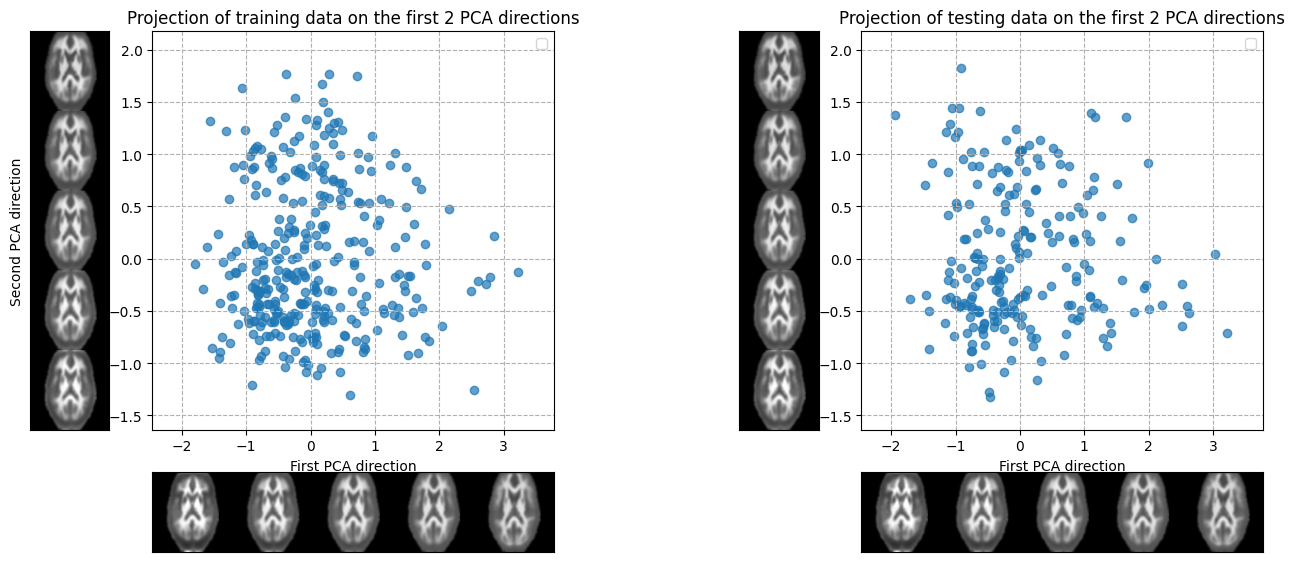

interactive(children=(IntSlider(value=48, description='Slice', max=95), Output()), _dom_classes=('widget-inter…

In [9]:
from pytranskit.TBM3D.visualization import *
images = visualize_pca(X_train_pca,X_test_pca,train_labels,test_labels,reference, pca, modes = [0], task = 'cca')

CCA

If you need to perform regression rather than classification, you can use CCA and linear regression. The TBM_forward and PCA operations are the same as before, except that you need to replace the class labels with real numbers. If you have more variables to analyze, you will need to read all your variables here and convert them to numpy arrays as input to CCA. For simplicity, we only show how to use regression models here.

(337, 143) (337, 1)
(226, 143) (226, 1)


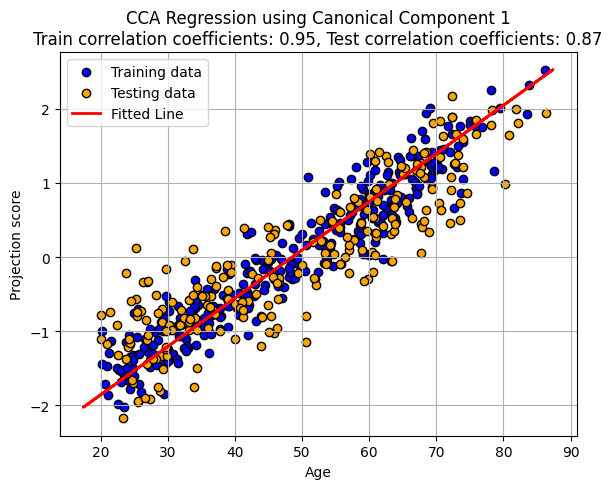

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pytranskit.optrans.decomposition import CCA
from sklearn.linear_model import LinearRegression

cca = CCA()
cca_proj_tr, cca_proj_tr_label = cca.fit_transform(X_train_pca,train_labels)
cca_proj_te = cca.transform(X_test_pca)

train_score, test_score = cca.score(X_train_pca, train_labels), cca.score(X_test_pca, test_labels)

reg = LinearRegression()
reg.fit(cca_proj_tr, train_labels)
Y_pred = reg.predict(cca_proj_tr)

plt.figure(figsize=(6,5))
# x: score, y: age
# plt.scatter(cca_proj_tr, train_labels, c='blue', edgecolor='k', label='Training data')
# plt.scatter(cca_proj_te, test_labels, c='orange', edgecolor='k', label='Testing data')
# plt.plot(cca_proj_tr, Y_pred, color='red', linewidth=2, label='Fitted Line')
# plt.xlabel("Projection score")
# plt.ylabel("Age")
# x: age, y: score
plt.scatter(train_labels, cca_proj_tr, c='blue', edgecolor='k', label='Training data')
plt.scatter(test_labels, cca_proj_te, c='orange', edgecolor='k', label='Testing data')
plt.plot(Y_pred, cca_proj_tr, color='red', linewidth=2, label='Fitted Line')
plt.ylabel("Projection score")
plt.xlabel("Age")
plt.title("CCA Regression using Canonical Component 1\nTrain correlation coefficients: {:.2f}, Test correlation coefficients: {:.2f}".format(train_score, test_score))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Visualize the regression results by sampling along the projection direction and performing inverse transforms to map them back to the image domain.

In [8]:
from pytranskit.TBM3D.visualization import *

data_std = np.std(cca_proj_tr)
vec = np.zeros((5,cca.n_components_))
stds = [-0.6,-0.3,0,0.3,0.6]
vec[:,0] = np.asarray(stds)*data_std

ages = reg.predict(np.asarray(stds).reshape(-1,1)*data_std)
ages = np.round(ages,1).flatten().tolist()
print(ages)

cca.mean_ = 0
inverse_pca = cca.inverse_transform(vec)
X_inverse = pca.inverse_transform(inverse_pca)
images = inverse_image(X_inverse, reference)
show_3d_arrays(images,stds=stds, titles=ages, fontsize=28)


/home/honeyk/project/Github/PyTransKit/pytranskit/TBM3D/visualization.py:54: SyntaxWarning: invalid escape sequence '\m'
  plt.title('$(D_{f}(\mathbf{x}))\'I_1( f(\mathbf{x}))$', fontsize=18)
/home/honeyk/project/Github/PyTransKit/pytranskit/TBM3D/visualization.py:214: RuntimeWarning: invalid value encountered in divide
  X_inverse_maps = X_inverse_maps/np.sqrt(reference)


[39.3, 43.9, 48.5, 53.1, 57.8]


interactive(children=(IntSlider(value=48, description='Slice', max=95), Output()), _dom_classes=('widget-inter…